<a href="https://colab.research.google.com/github/AnindyaNaura12/Data-Mining/blob/main/RealEstate_Prak6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Real estate.csv to Real estate.csv


In [3]:
data = pd.read_csv("Real estate.csv")
data.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
data = data[data['Y house price of unit area'] <= 70]

In [7]:
X = data[['X2 house age',
        'X3 distance to the nearest MRT station',
        'X4 number of convenience stores',
        'X5 latitude', 'X6 longitude']]

y = data['Y house price of unit area']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.333, random_state=42
)

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: -11217.244670424509
Slope: -0.3125559502560592


In [23]:
y_pred = model.predict(X_test)

In [24]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 8.654846771240534
R2 Score: 0.5413533399383144


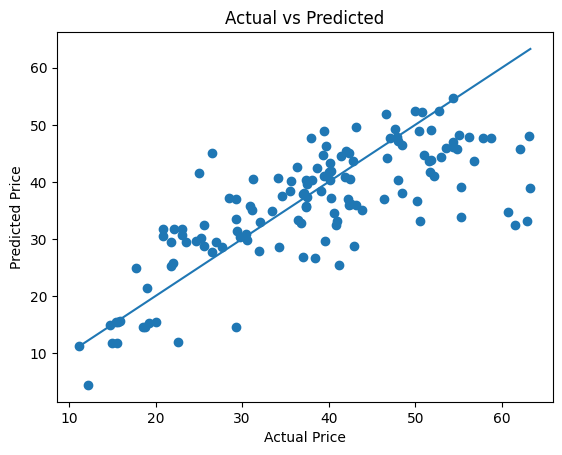

In [33]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

# garis diagonal (ideal)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()